Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import Data

In [2]:
data = pd.read_csv('for_unsupervised.csv')
data = data.drop(['C_Occasion', 'T_Occasion'], axis=1)
data.shape

(167, 22)

In [16]:
data.info()
print('='*50)
data.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   C_Fresh_Taste   118 non-null    float64
 1   C_Intense       118 non-null    float64
 2   C_Smooth        118 non-null    float64
 3   C_Acidic        118 non-null    float64
 4   C_Aroma         118 non-null    float64
 5   C_Alert         118 non-null    float64
 6   C_Origin        118 non-null    float64
 7   C_Portable      118 non-null    float64
 8   C_Value         118 non-null    float64
 9   C_Nutrition     118 non-null    float64
 10  C_Brand_Trust   118 non-null    float64
 11  C_Premium_Look  118 non-null    float64
 12  T_Aroma         143 non-null    float64
 13  T_Intense       143 non-null    float64
 14  T_No_Sugar      143 non-null    float64
 15  T_Zero_Cal      143 non-null    float64
 16  T_Nutrition     143 non-null    float64
 17  T_Origin        143 non-null    flo

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look,is_anomaly
0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,4.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,1
1,5.0,3.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,4.0,5.0,5.0,4.0,4.0,3.0,5.0,3.0,5.0,0
2,1.0,1.0,5.0,1.0,2.0,5.0,1.0,2.0,2.0,2.0,...,2.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,0
3,5.0,5.0,5.0,1.0,5.0,3.0,2.0,3.0,1.0,3.0,...,5.0,5.0,5.0,3.0,2.0,2.0,3.0,3.0,4.0,0
4,4.0,4.0,5.0,2.0,4.0,4.0,4.0,5.0,4.0,5.0,...,4.0,3.0,3.0,3.0,4.0,3.0,4.0,5.0,4.0,0
5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,5.0,5.0,1.0,5.0,3.0,3.0,3.0,3.0,3.0,0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0,0
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,2.0,2.0,1.0,3.0,3.0,3.0,1.0,1.0,0
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,4.0,3.0,4.0,4.0,4.0,4.0,5.0,5.0,0
9,5.0,3.0,5.0,4.0,5.0,5.0,1.0,1.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [4]:
data.describe().round(2)

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Aroma,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look
count,118.00,118.00,118.00,118.00,118.00,118.00,118.00,118.00,118.00,118.00,...,143.00,143.00,143.00,143.00,143.00,143.00,143.00,143.00,143.00,143.00
mean,4.08,3.73,3.92,2.42,4.05,3.66,3.03,3.94,3.47,3.40,...,4.38,4.13,4.04,3.64,3.64,3.42,3.27,4.13,3.83,3.78
std,1.20,1.21,1.21,1.30,1.15,1.25,1.29,1.18,1.38,1.24,...,0.77,0.86,1.13,1.24,1.10,0.98,1.03,0.84,1.07,1.04
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,3.25,3.00,3.00,1.00,4.00,3.00,2.00,3.00,3.00,3.00,...,4.00,4.00,4.00,3.00,3.00,3.00,3.00,4.00,3.00,3.00
50%,5.00,4.00,4.00,2.00,4.00,4.00,3.00,4.00,4.00,4.00,...,5.00,4.00,4.00,4.00,4.00,3.00,3.00,4.00,4.00,4.00
75%,5.00,5.00,5.00,3.00,5.00,5.00,4.00,5.00,5.00,4.00,...,5.00,5.00,5.00,5.00,4.00,4.00,4.00,5.00,5.00,5.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


Correlation Anlysis

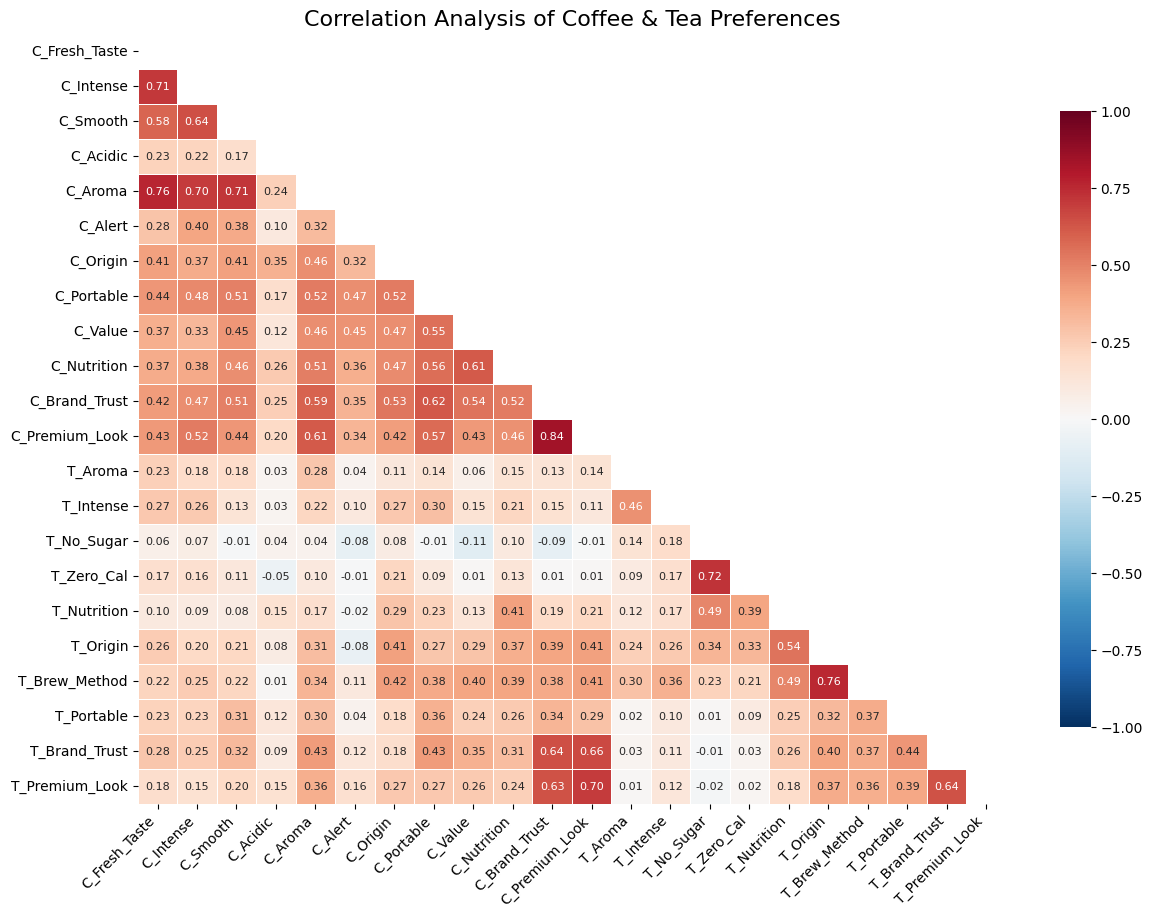

In [5]:
# คำนวณ Correlation
corr = data.corr()

# สร้าง Mask เพื่อปิดครึ่งบนไม่ให้ข้อมูลซ้ำซ้อน
mask = np.triu(np.ones_like(corr, dtype=bool))

# ตั้งค่ากราฟให้ใหญ่พอสำหรับ 20+ Features
f, ax = plt.subplots(figsize=(14, 10))

# พล็อต Heatmap 
sns.heatmap(corr, 
            mask=mask, 
            cmap='RdBu_r',     
            vmax=1, vmin=-1, 
            center=0,
            annot=True,        
            fmt=".2f",          
            linewidths=.5, 
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8}) 

plt.title('Correlation Analysis of Coffee & Tea Preferences', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

Anomaly Detection (Variance)

In [12]:
# คำนวณ Variance รายแถว (axis=1) ก่อนทำการ Scaling
row_variance = data.var(axis=1)

# กำหนดเกณฑ์ (เช่น ถ้าตอบเหมือนกันเกือบหมด Variance จะต่ำมาก)
threshold = 0.1 
is_anomaly = row_variance < threshold

# ตัดออกหรือเก็บเฉพาะคนที่มีความหลากหลายในการตอบ
data.loc[row_variance < threshold, 'is_anomaly'] = 1
data.fillna(0)

print(f"พบ Anomaly: {(data['is_anomaly'] == 1).sum()} ราย")

พบ Anomaly: 9 ราย


In [15]:
data.isnull().sum()

C_Fresh_Taste     49
C_Intense         49
C_Smooth          49
C_Acidic          49
C_Aroma           49
C_Alert           49
C_Origin          49
C_Portable        49
C_Value           49
C_Nutrition       49
C_Brand_Trust     49
C_Premium_Look    49
T_Aroma           24
T_Intense         24
T_No_Sugar        24
T_Zero_Cal        24
T_Nutrition       24
T_Origin          24
T_Brew_Method     24
T_Portable        24
T_Brand_Trust     24
T_Premium_Look    24
is_anomaly         0
dtype: int64

Feaures Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

# 1. แยกคอลัมน์ที่ไม่ต้องการสเกลออกมาเก็บไว้ก่อน
is_anomaly_col = data['is_anomaly']

# 2. เลือกเฉพาะคอลัมน์ที่เป็น Feature (ตัวเลข 1-5) มาสเกล
# โดยการ drop คอลัมน์ที่เราไม่ต้องการสเกลออก
features_to_scale = data.drop(columns=['is_anomaly']) 

# 3. ทำการ Scaling
scaler = StandardScaler()
scaled_array = scaler.fit_transform(features_to_scale)

# 4. สร้าง DataFrame ใหม่จากค่าที่สเกลแล้ว
data_scaled = pd.DataFrame(scaled_array, columns=features_to_scale.columns, index=data.index)

# 5. เอาคอลัมน์ที่แยกไว้ตอนแรก กลับไปแปะคืน
data_scaled['is_anomaly'] = is_anomaly_col

data_scaled.head()

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look,is_anomaly
0,-0.911407,-0.604854,-0.759961,0.450672,-0.920770,-0.53161,-0.019781,-0.801387,-0.340305,-0.322243,...,-1.325378,-0.037424,-0.514116,-0.578411,-0.428944,-0.257830,-0.150724,-0.781914,-0.750823,1
1,0.769000,-0.604854,0.900694,0.450672,-0.920770,-0.53161,-0.019781,-0.801387,-0.340305,-0.322243,...,-0.155446,0.854516,1.101677,0.330520,0.593372,-0.257830,1.046694,-0.781914,1.183730,0
2,-2.591814,-2.264687,0.900694,-1.090758,-1.796986,1.07685,-1.575885,-1.653311,-1.070413,-1.131279,...,-2.495310,-2.713244,-2.129910,-2.396272,-2.473575,-2.198341,-1.348142,-2.661136,-0.750823,0
3,0.769000,1.054979,0.900694,-1.090758,0.831663,-0.53161,-0.797833,-0.801387,-1.800521,-0.322243,...,1.014487,0.854516,1.101677,-0.578411,-1.451259,-1.228086,-1.348142,-0.781914,0.216454,0
4,-0.071204,0.225062,0.900694,-0.320043,-0.044553,0.27262,0.758271,0.902462,0.389803,1.295828,...,-0.155446,-0.929364,-0.514116,-0.578411,0.593372,-0.257830,-0.150724,1.097308,0.216454,0


Dimensionality Reduction (PCA)

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

print(data_pca.shape)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Plot Anomaly

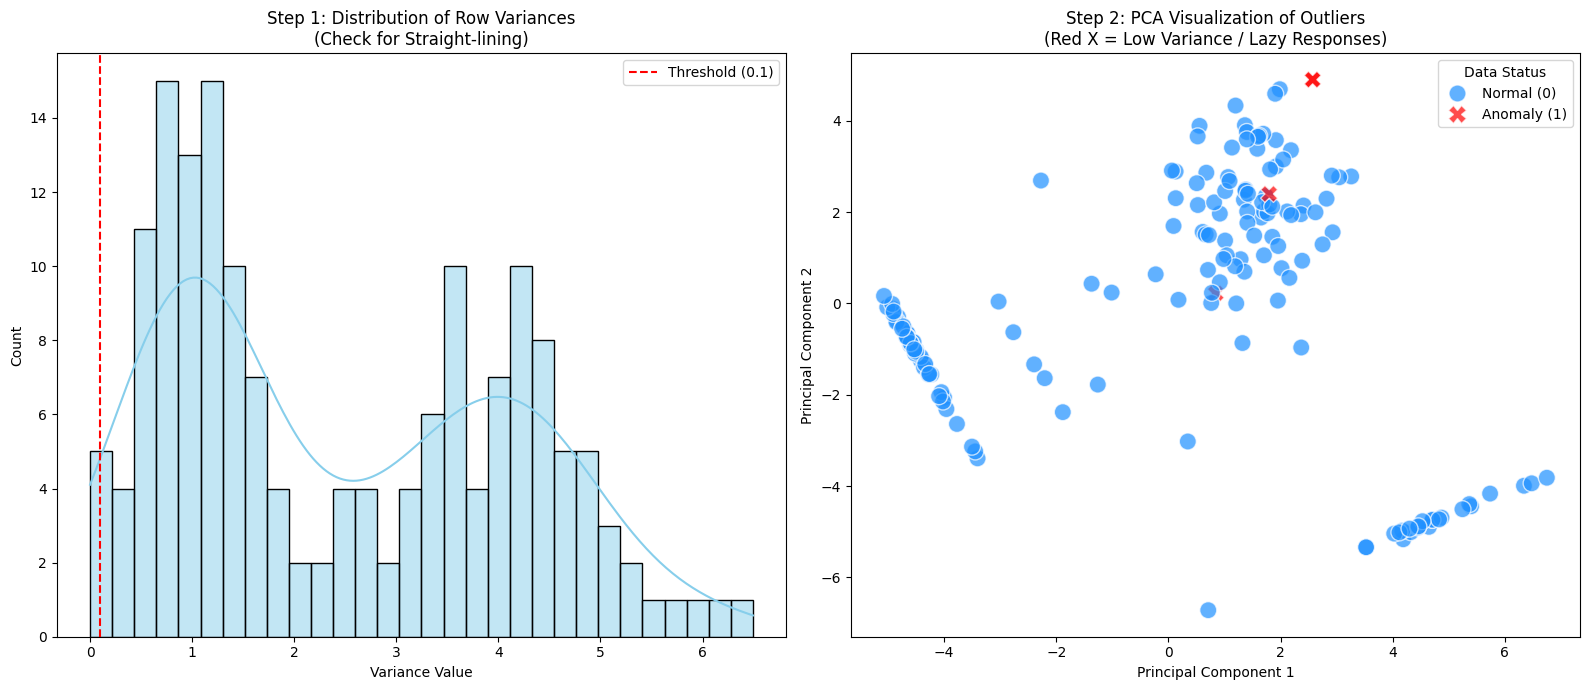

--- สรุปผลการตรวจสอบคุณภาพข้อมูล ---
จำนวนข้อมูลปกติ (0): 163 ราย
จำนวน Anomaly (1): 4 ราย (ตรวจพบจากการตอบซ้ำเดิม)


In [10]:
# --- ส่วนการคำนวณและเตรียมข้อมูล (รันส่วนนี้เพื่อให้มั่นใจว่าค่าถูกต้อง) ---

# 1. คำนวณ Variance รายแถว
row_variance = data.drop(columns=['row_id', 'is_anomaly'], errors='ignore').var(axis=1)

# 2. กำหนดค่า 0 (ปกติ) และ 1 (Anomaly)
threshold = 0.1
data['is_anomaly'] = (row_variance < threshold).astype(int)

# 3. เตรียม DataFrame สำหรับ Plot
plot_df = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])
plot_df['is_anomaly'] = data['is_anomaly'].values
plot_df['variance'] = row_variance.values

# --- ส่วนการ Plot ---

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# กราฟที่ 1: ดูการกระจายของค่า Variance (ตรวจสอบเกณฑ์ Threshold)
sns.histplot(plot_df['variance'], bins=30, kde=True, ax=ax[0], color='skyblue')
ax[0].axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
ax[0].set_title('Step 1: Distribution of Row Variances\n(Check for Straight-lining)')
ax[0].set_xlabel('Variance Value')
ax[0].legend()

# กราฟที่ 2: PCA Scatter Plot เน้นแยกแค่ "ปกติ" กับ "Outlier"
# 0 = Normal (วงกลม สีฟ้า), 1 = Anomaly (กากบาท สีแดง)
sns.scatterplot(
    data=plot_df, 
    x='PC1', y='PC2', 
    hue='is_anomaly',            
    palette={0: 'dodgerblue', 1: 'red'}, 
    style='is_anomaly',          
    markers={0: 'o', 1: 'X'},    
    s=150,                       # ปรับขนาดจุดให้ใหญ่ขึ้นเล็กน้อย
    alpha=0.7,
    ax=ax[1]
)

ax[1].set_title('Step 2: PCA Visualization of Outliers\n(Red X = Low Variance / Lazy Responses)')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')

# ปรับคำอธิบายใน Legend ให้เข้าใจง่าย
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles, ['Normal (0)', 'Anomaly (1)'], title='Data Status')

plt.tight_layout()
plt.show()

# สรุปผลทางหน้าจอ
print(f"--- สรุปผลการตรวจสอบคุณภาพข้อมูล ---")
print(f"จำนวนข้อมูลปกติ (0): {(data['is_anomaly'] == 0).sum()} ราย")
print(f"จำนวน Anomaly (1): {(data['is_anomaly'] == 1).sum()} ราย (ตรวจพบจากการตอบซ้ำเดิม)")

Elbow Method for KMeans

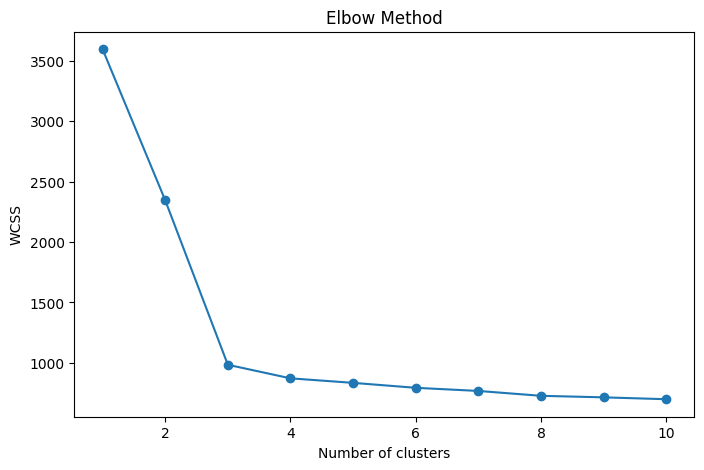

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data_clustering = data_scaled[data_scaled['is_anomaly'] == 0].drop(columns=['is_anomaly'])
# ใช้ data_for_clustering ที่เตรียมไว้
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data_clustering)
    wcss.append(kmeans.inertia_)

# พล็อตกราฟ Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Clustering (K-Means)

In [17]:
# Fit KMeans ด้วยข้อมูลที่ไม่มี Anomaly
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(data_clustering)
clusters = kmeans.predict(data_clustering)
# Predict และเก็บค่าลงใน data_scaled
data_scaled['Cluster_ID'] = -1

data_scaled.loc[data_scaled['is_anomaly'] == 0, 'Cluster_ID'] = clusters

# ตรวจสอบผล
print(data_scaled['Cluster_ID'].value_counts())

Cluster_ID
 1    83
 2    55
 0    25
-1     4
Name: count, dtype: int64


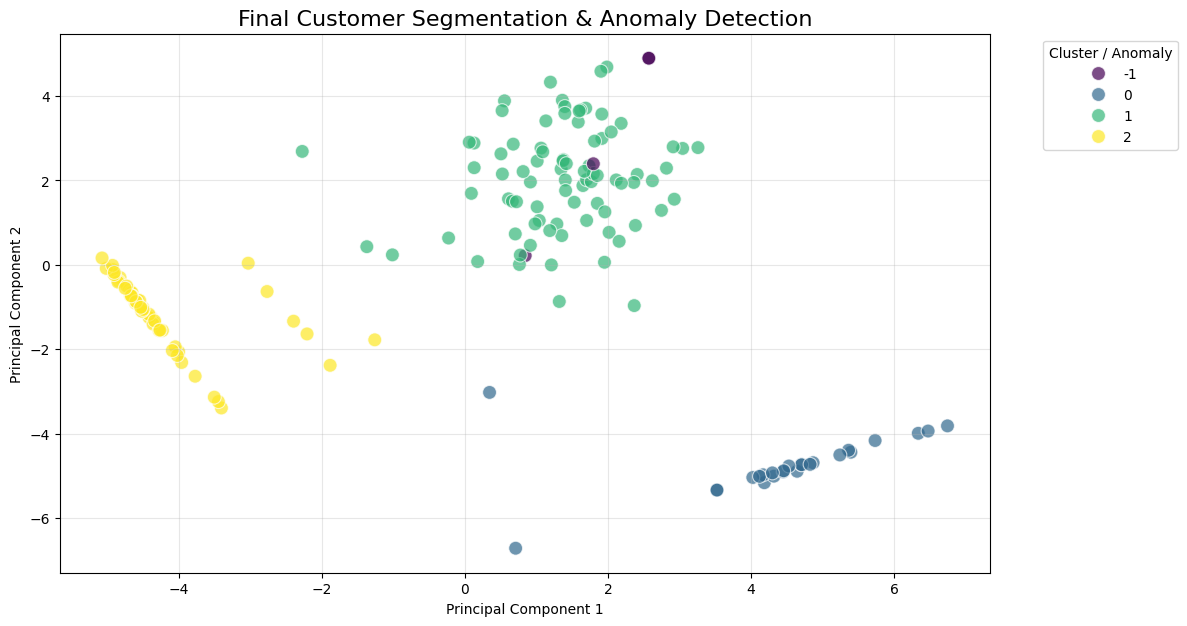

In [18]:
# 1. แปลง data_pca เป็น DataFrame (ถ้าปัจจุบันยังเป็น numpy array)
# ตรวจสอบว่าคุณมี 2 แกนหลัก (PC1, PC2)
df_plot = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])

# 2. แปะผลลัพธ์ Cluster_ID และ is_anomaly ลงไป
# เราใช้ .values เพื่อให้แน่ใจว่ามันจะวางเรียงตามลำดับแถวได้ถูกต้อง
df_plot['Cluster_ID'] = data_scaled['Cluster_ID'].values

# 3. พล็อตกราฟแบบโปรอาชีพ
plt.figure(figsize=(12, 7))

# ใช้ hue แยกสีตาม Cluster_ID
# และใช้ style แยกรูปร่างตาม is_anomaly (เช่น จุดปกติเป็นวงกลม, Anomaly เป็นกากบาท)
sns.scatterplot(
    data=df_plot, 
    x='PC1', y='PC2', 
    hue='Cluster_ID', 
    palette='viridis', 
    s=100, 
    alpha=0.7
)

plt.title('Final Customer Segmentation & Anomaly Detection', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster / Anomaly', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

            C_Fresh_Taste  C_Intense  C_Smooth  C_Acidic   C_Aroma   C_Alert  \
Cluster_ID                                                                     
-1               4.250000   4.250000  4.250000  4.250000  4.250000  4.250000   
 0               4.040000   3.400000  4.000000  2.800000  4.080000  3.600000   
 1               4.313253   4.000000  4.084337  2.313253  4.253012  3.795181   
 2               0.109091   0.109091  0.109091  0.109091  0.109091  0.181818   

            C_Origin  C_Portable   C_Value  C_Nutrition  ...   T_Aroma  \
Cluster_ID                                               ...             
-1          4.250000    4.250000  4.250000     4.250000  ...  4.250000   
 0          3.200000    3.920000  3.960000     3.720000  ...  0.160000   
 1          3.060241    4.120482  3.457831     3.433735  ...  4.493976   
 2          0.109091    0.145455  0.109091     0.109091  ...  4.236364   

            T_Intense  T_No_Sugar  T_Zero_Cal  T_Nutrition  T_Origin  \
Cl

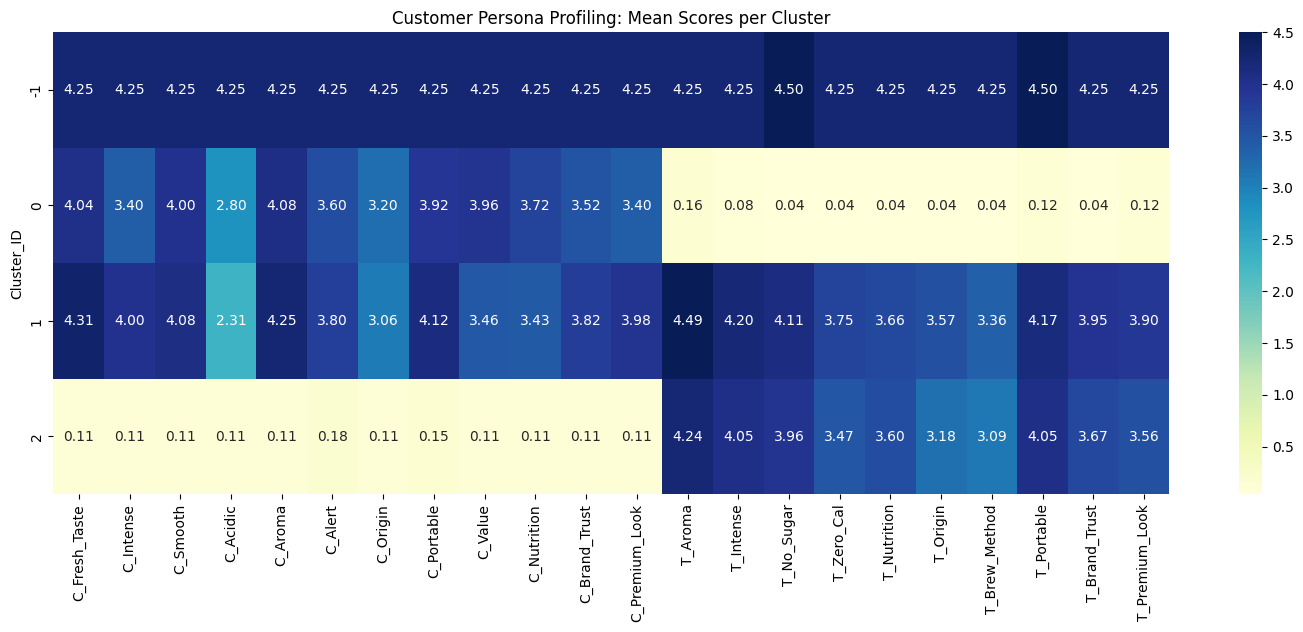

In [19]:
data['Cluster_ID'] = -1
data.loc[data['is_anomaly'] == 0, 'Cluster_ID'] = clusters

# กำหนดรายชื่อคอลัมน์ (Features) ที่จะใช้ทำ Profiling 
# โดยเลือกเฉพาะคอลัมน์ที่ขึ้นต้นด้วย C_ (Coffee) และ T_ (Tea) เท่านั้น
feautres = [col for col in data.columns if col.startswith('C_') or col.startswith('T_')]

# ทำ Profiling โดยการหาค่าเฉลี่ย (Mean) แยกตามกลุ่ม Cluster_ID
cluster_profile = data.groupby('Cluster_ID')[feautres].mean()

print(cluster_profile)
# แสดงผล Heatmap เพื่อวิเคราะห์จุดเด่นของแต่ละกลุ่ม 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Customer Persona Profiling: Mean Scores per Cluster')
plt.show()

In [20]:
# สร้าง row_id จาก Index เพื่อใช้เป็น Key ในการ Merge ข้อมูล 
data_scaled['row_id'] = data_scaled.index 

# เลือกเฉพาะคอลัมน์สำคัญ
final_unsup_output = data_scaled[['row_id', 'Cluster_ID']]

# Export ไฟล์ CSV 
final_unsup_output.to_csv('unsupervised_results.csv', index=False)
print("Export Unsupervised Results Success!")

Export Unsupervised Results Success!
